In [42]:
# baseline model

In [43]:
# Load data + filter countries (>20 samples)

In [44]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

def load_data(address):
    df = pd.DataFrame(pd.read_csv(address))
    return df
df = load_data('cost-of-living_v2.csv')
min_samples = 20
valid_country_names = df['country'].value_counts()
valid_country_names = valid_country_names[valid_country_names >= min_samples].index
filtered_df = df[df['country'].isin(valid_country_names)]
print("Number of countries:", filtered_df['country'])
filtered_df['country'].value_counts()

Number of countries: 0       South Korea
1             China
2             China
3             India
4             India
           ...     
4949      Australia
4951      Australia
4952      Australia
4953         Mexico
4954         Canada
Name: country, Length: 4174, dtype: str


country
United States      1073
Italy               186
India               167
Brazil              164
United Kingdom      160
Germany             147
Russia              139
Canada              120
France              113
China               104
Spain                88
Mexico               87
Philippines          77
Japan                75
Poland               66
Australia            64
Turkey               61
Netherlands          55
Romania              53
Portugal             52
Ukraine              45
Hungary              44
Czech Republic       44
Switzerland          43
Indonesia            40
Pakistan             39
Belgium              39
Thailand             37
Iran                 37
Greece               36
South Africa         34
Algeria              34
Serbia               34
Israel               34
Slovakia             34
Malta                34
Morocco              32
Nigeria              31
Bulgaria             30
Sweden               30
South Korea          29
Argentin

In [45]:
#Add column name

In [46]:
feature_names = [
    'Milk', 'Bread', 'Rice', 'Eggs', 'Local Cheese',
    'Chicken Fillets', 'Beef Round', 'Apples', 'Banana',
    'Oranges', 'Tomato', 'Potato', 'Onion', 'Lettuce',
    'Water', 'Bottle of Wine', 'Domestic Beer', 'Imported Beer'
]
grocery_cols = [f'x{i}' for i in range(9, 27)]
identity_cols = ['city', 'country']

grocery_df = filtered_df[identity_cols + grocery_cols].copy()
grocery_cols_features = {f'x{i}': name for i, name in zip(range(9, 27), feature_names)}
grocery_df = grocery_df.rename(columns=grocery_cols_features)
grocery_df.head()

,city,country,Milk,Bread,Rice,Eggs,Local Cheese,Chicken Fillets,Beef Round,Apples,Banana,Oranges,Tomato,Potato,Onion,Lettuce,Water,Bottle of Wine,Domestic Beer,Imported Beer
0,Seoul,South Korea,2.20,2.85,3.53,4.04,11.54,10.58,41.61,6.77,3.71,6.50,6.19,3.84,2.92,2.45,1.05,15.36,2.12,2.36
1,Shanghai,China,2.74,2.61,1.22,2.22,18.35,4.86,13.12,2.26,1.60,2.19,1.53,0.84,1.04,0.83,0.64,14.24,0.94,1.97
2,Guangzhou,China,1.91,1.63,1.03,1.71,9.00,3.77,11.75,2.02,1.44,1.82,1.31,0.74,1.00,0.49,0.51,11.39,0.95,2.26
3,Mumbai,India,0.75,0.50,0.83,0.95,5.88,3.69,5.95,2.09,0.67,1.34,0.59,0.44,0.44,0.65,0.35,9.83,2.27,3.61
4,Delhi,India,0.73,0.50,0.85,1.02,4.36,3.81,5.71,1.79,0.75,1.03,0.61,0.37,0.41,0.70,0.36,9.83,1.54,2.49


In [47]:
grocery_df.shape

(4174, 20)

In [48]:
def count_the_missing_values_of_each_column(df):
    missing_values_series = df.isnull().sum()
    return missing_values_series

missing_values_series = count_the_missing_values_of_each_column(grocery_df)
print(missing_values_series)

city                 0
country              0
Milk               321
Bread              353
Rice               277
Eggs               455
Local Cheese       381
Chicken Fillets    493
Beef Round         486
Apples             295
Banana             303
Oranges            355
Tomato             397
Potato             363
Onion              352
Lettuce            387
Water              313
Bottle of Wine     360
Domestic Beer      612
Imported Beer      539
dtype: int64


In [49]:
grocery_df_imputed = grocery_df.fillna(grocery_df.mean(numeric_only=True))
missing_values_series = count_the_missing_values_of_each_column(grocery_df_imputed)
print(missing_values_series)

city               0
country            0
Milk               0
Bread              0
Rice               0
Eggs               0
Local Cheese       0
Chicken Fillets    0
Beef Round         0
Apples             0
Banana             0
Oranges            0
Tomato             0
Potato             0
Onion              0
Lettuce            0
Water              0
Bottle of Wine     0
Domestic Beer      0
Imported Beer      0
dtype: int64


In [50]:
# Price index

In [51]:
usd_df = grocery_df_imputed.copy()


usd_df['Total_Basket'] = usd_df[feature_names].sum(axis=1)


usa_baseline = usd_df[usd_df['country'] == 'United States']['Total_Basket'].median()

usd_df['Grocery_Price_Index'] = usd_df['Total_Basket'] / usa_baseline


grocery_df_imputed['Grocery_Price_Index'] = usd_df['Grocery_Price_Index']
grocery_df_imputed.head()

,city,country,Milk,Bread,Rice,Eggs,Local Cheese,Chicken Fillets,Beef Round,Apples,...,Oranges,Tomato,Potato,Onion,Lettuce,Water,Bottle of Wine,Domestic Beer,Imported Beer,Grocery_Price_Index
0,Seoul,South Korea,2.20,2.85,3.53,4.04,11.54,10.58,41.61,6.77,...,6.50,6.19,3.84,2.92,2.45,1.05,15.36,2.12,2.36,1.514960
1,Shanghai,China,2.74,2.61,1.22,2.22,18.35,4.86,13.12,2.26,...,2.19,1.53,0.84,1.04,0.83,0.64,14.24,0.94,1.97,0.855540
2,Guangzhou,China,1.91,1.63,1.03,1.71,9.00,3.77,11.75,2.02,...,1.82,1.31,0.74,1.00,0.49,0.51,11.39,0.95,2.26,0.639668
3,Mumbai,India,0.75,0.50,0.83,0.95,5.88,3.69,5.95,2.09,...,1.34,0.59,0.44,0.44,0.65,0.35,9.83,2.27,3.61,0.477209
4,Delhi,India,0.73,0.50,0.85,1.02,4.36,3.81,5.71,1.79,...,1.03,0.61,0.37,0.41,0.70,0.36,9.83,1.54,2.49,0.430809


In [52]:
#Split x,y

In [53]:
X = grocery_df_imputed[feature_names + ['Grocery_Price_Index']]
y = grocery_df_imputed['country']

In [54]:
#Baseline model

In [55]:
#Split trainset and testset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [56]:
#StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [57]:
#Build a simple logistic regression model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Accuracy: 0.8275449101796407
Macro F1: 0.7693631677442332


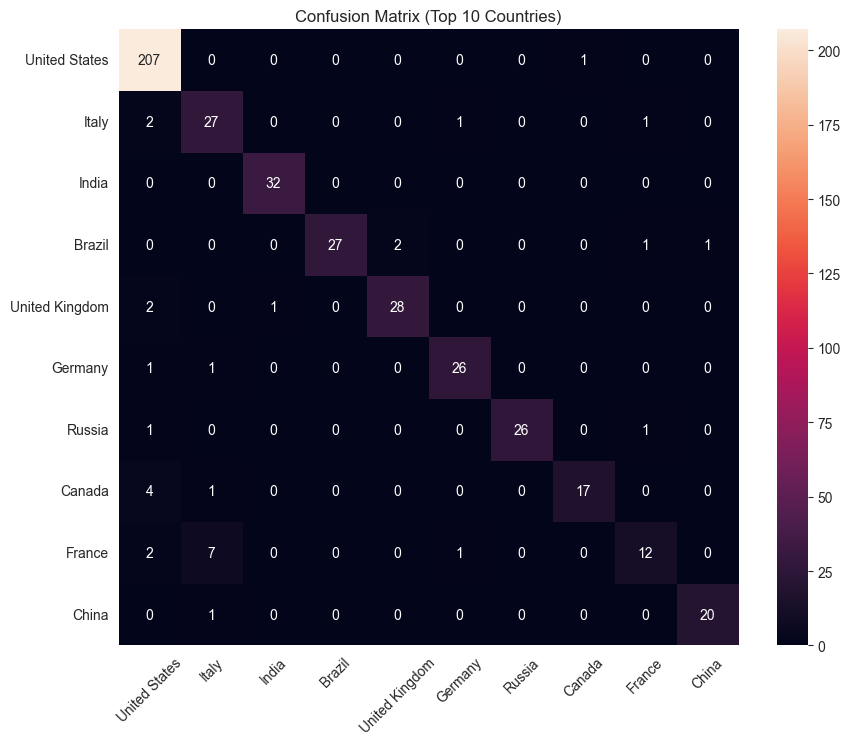

In [60]:
#Evaluation
from sklearn.metrics import ConfusionMatrixDisplay
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
top_countries = y_test.value_counts().head(10).index

mask = y_test.isin(top_countries)

cm = confusion_matrix(
    y_test[mask],
    y_pred[mask],
    labels=top_countries
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=top_countries,
    yticklabels=top_countries
)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.title("Confusion Matrix (Top 10 Countries)")
plt.show()